In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from sqlalchemy import create_engine
from pathlib import Path
import numpy as np
import os

In [2]:
print(os.getcwd())

/Users/trba/Documents/Projects/Serbia_housing/machine_learning


In [3]:
env_path = Path("/Users/trba/Documents/Projects/Serbia_housing/.env.aws")
load_dotenv(env_path)

True

In [4]:
engine = create_engine(f"postgresql+psycopg2://{os.getenv("DB_USER")}:{os.getenv("DB_PASSWORD")}@{os.getenv("DB_HOST")}:{os.getenv("DB_PORT")}/{os.getenv("DB_NAME")}")

In [5]:
df = pd.read_sql("SELECT * FROM gold.unified_deduplicated",engine)

In [6]:
print(f"Broj oglasa: {len(df)}")
print(f"Kolone: {df.columns.tolist()}")

Broj oglasa: 23680
Kolone: ['stan_id', 'oglas_id', 'izvor', 'url', 'title', 'price_total', 'price_avg', 'price_per_m2', 'tip_nekretnine', 'kvadratura', 'broj_soba', 'oglasivac', 'tip_objekta', 'stanje_objekta', 'grejanje', 'sprat', 'ukupna_spratnost', 'uknjizen', 'terasa', 'interfon', 'klima', 'video_nadzor', 'internet', 'parking', 'garaza', 'lift', 'podrum', 'linije_gradskog_prevoza', 'datum_objave', 'dodatni_opis', 'lokacija', 'created_at']


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 23680 entries, 0 to 23679
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   stan_id                  23680 non-null  str           
 1   oglas_id                 23680 non-null  str           
 2   izvor                    23680 non-null  str           
 3   url                      23680 non-null  str           
 4   title                    23669 non-null  str           
 5   price_total              23680 non-null  float64       
 6   price_avg                23680 non-null  float64       
 7   price_per_m2             23673 non-null  float64       
 8   tip_nekretnine           19994 non-null  str           
 9   kvadratura               23680 non-null  float64       
 10  broj_soba                23680 non-null  float64       
 11  oglasivac                10857 non-null  str           
 12  tip_objekta              6265 non-null   st

In [8]:
df.describe()

,price_total,price_avg,price_per_m2,kvadratura,broj_soba,sprat,ukupna_spratnost,created_at
count,2.368000e+04,2.368000e+04,23673.000000,23680.000000,23680.000000,22231.000000,11538.00000,23680
mean,2.780412e+05,2.780412e+05,17866.123812,78.127184,2.831820,3.229252,5.82770,2026-04-15 14:54:41.422449
min,2.500000e+04,2.500000e+04,0.000000,15.000000,0.500000,-1.000000,1.00000,2026-04-09 14:55:15.522204
25%,1.450000e+05,1.457500e+05,3133.000000,51.000000,2.000000,1.000000,3.00000,2026-04-10 18:24:34.997794
50%,2.190000e+05,2.190000e+05,5269.000000,68.000000,3.000000,2.000000,5.00000,2026-04-11 09:46:41.947112
75%,3.330000e+05,3.336362e+05,32032.000000,94.000000,3.500000,4.000000,7.00000,2026-04-16 17:20:26.779426
max,2.000000e+06,2.000000e+06,200002.000000,400.000000,20.000000,37.000000,42.00000,2026-05-04 07:30:24.232728
std,2.171039e+05,2.170170e+05,18353.936872,41.575113,1.120952,3.397280,4.71064,NaN


In [7]:
df["datum_objave"] = pd.to_datetime(df["datum_objave"])
n_pre = len(df)
df = df[df["datum_objave"] >= "2025-01-01"].copy()
print(f"\nOdbačeno pre 2025: {n_pre - len(df)} | Ostalo: {len(df)}")
print(f"Raspon: {df['datum_objave'].min().date()} → {df['datum_objave'].max().date()}")


Odbačeno pre 2025: 3787 | Ostalo: 19893
Raspon: 2025-01-05 → 2026-05-04


In [9]:
null_values = (df.isnull().sum() / len(df) * 100).sort_values(ascending = False)
print(null_values.round(1))

video_nadzor               84.1
podrum                     79.6
garaza                     75.5
tip_objekta                73.5
linije_gradskog_prevoza    72.2
parking                    59.9
internet                   55.3
oglasivac                  54.2
ukupna_spratnost           51.3
klima                      48.4
uknjizen                   46.1
lift                       43.6
interfon                   34.6
stanje_objekta             25.6
terasa                     23.7
tip_nekretnine             15.6
datum_objave               13.4
grejanje                    7.0
sprat                       6.1
lokacija                    1.9
dodatni_opis                0.1
title                       0.0
price_per_m2                0.0
stan_id                     0.0
oglas_id                    0.0
broj_soba                   0.0
kvadratura                  0.0
price_avg                   0.0
price_total                 0.0
url                         0.0
izvor                       0.0
created_

In [8]:
df["price_per_m2_cal"] = df["price_total"] / df["kvadratura"]


In [9]:
print(f"Originalna cena: {df["price_per_m2"]}")
print(f"Izracunata cena cena: {df["price_per_m2_cal"]}")

Originalna cena: 0        38522.0
1        42902.0
2        63292.0
3        32042.0
4        18702.0
          ...   
23674     1607.0
23675     2527.0
23676     2553.0
23678     4000.0
23679     2782.0
Name: price_per_m2, Length: 19893, dtype: float64
Izracunata cena cena: 0        3852.459016
1        4518.766258
2        5365.732039
3        3393.203883
4        2024.147727
            ...     
23674    1607.142857
23675    2527.027027
23676    2553.191489
23678    4000.000000
23679    2782.258065
Name: price_per_m2_cal, Length: 19893, dtype: float64


In [10]:
df["razlika"] = df["price_per_m2"] - df["price_per_m2_cal"]
df["razlika_abs"] = df["razlika"].abs()

In [11]:
print(f"Razlika u ceni: {df["razlika"].round(2)}")
print(f"Razlika u ceni abs: {df["razlika_abs"].round(2)}")

Razlika u ceni: 0        34669.54
1        38383.23
2        57926.27
3        28648.80
4        16677.85
           ...   
23674       -0.14
23675       -0.03
23676       -0.19
23678       -0.00
23679       -0.26
Name: razlika, Length: 19893, dtype: float64
Razlika u ceni abs: 0        34669.54
1        38383.23
2        57926.27
3        28648.80
4        16677.85
           ...   
23674        0.14
23675        0.03
23676        0.19
23678        0.00
23679        0.26
Name: razlika_abs, Length: 19893, dtype: float64


In [12]:
###### STATISTIKA ####
print(f"Cena se razlikuje za manje od 1%:   {(df["razlika_abs"] < 0.01).sum()} / {len(df)}")
print(f"Cena se razlikuje za ili vise od 1%:   {(df["razlika_abs"] >= 0.01).sum()}")
print(f"MAKS razlika u ceni:   {df["razlika_abs"].max():.2f} EUR/m2")
print(f"SREDNJA razlika u ceni:   {df["razlika_abs"].mean():.2f} EUR/m2")

Cena se razlikuje za manje od 1%:   2737 / 19893
Cena se razlikuje za ili vise od 1%:   17149
MAKS razlika u ceni:   186775.61 EUR/m2
SREDNJA razlika u ceni:   12299.08 EUR/m2


In [13]:
outlieri = df[df["razlika_abs"] >= 1].sort_values("razlika_abs", ascending=False)
print(f"\n=== Top 10 neslaganja ===")
print(outlieri[["oglas_id", "price_total", "kvadratura", 
                "price_per_m2", "price_per_m2_cal", "razlika"]].head(10).to_string())


=== Top 10 neslaganja ===
           oglas_id  price_total  kvadratura  price_per_m2  price_per_m2_cal        razlika
220   5425646979175     145000.0      147.00      187762.0        986.394558  186775.605442
6257  5425646947866    1470000.0       73.00      200002.0      20136.986301  179865.013699
222   5425646979174    1500000.0       74.00      198652.0      20270.270270  178381.729730
2372  5425646449478     590000.0       61.04      119922.0       9665.792923  110256.207077
7423  5425646931127    1000000.0       88.00      113642.0      11363.636364  102278.363636
2793  5425646866602    1498000.0      164.00      109762.0       9134.146341  100627.853659
9765  5425646184757    1400000.0      136.26      110082.0      10274.475268   99807.524732
6327  5425646699568    1800000.0      163.50      110092.0      11009.174312   99082.825688
3818  5425645298684    1500000.0      138.00      108702.0      10869.565217   97832.434783
6452  5425644727538     160000.0      204.00       98

In [14]:
mask = df["sprat"].notna() & df["ukupna_spratnost"].notna() & (df["ukupna_spratnost"] != 0)

In [15]:
df.loc[mask,"sprat_ratio"] = df.loc[mask,"sprat"] / df.loc[mask,"ukupna_spratnost"]
print(df["sprat_ratio"].value_counts(dropna=False))

sprat_ratio
 NaN         11582
 1.000000     1860
 0.500000      807
 0.000000      735
 0.333333      534
             ...  
-0.083333        1
 1.250000        1
 0.937500        1
 0.263158        1
-0.062500        1
Name: count, Length: 181, dtype: int64


In [16]:
df["sprat_ratio"] = df.loc[mask, "sprat"] / df.loc[mask, "ukupna_spratnost"]
print(df["sprat_ratio"].value_counts(dropna=False))

sprat_ratio
 NaN         11582
 1.000000     1860
 0.500000      807
 0.000000      735
 0.333333      534
             ...  
-0.083333        1
 1.250000        1
 0.937500        1
 0.263158        1
-0.062500        1
Name: count, Length: 181, dtype: int64


In [19]:
outlier = df[df["sprat_ratio"] > 1]["url"]
pd.set_option("display.max_colwidth", None)
print(outlier.to_string())

181                                                           https://www.nekretnine.rs/stambeni-objekti/stanovi/na-prodaju-dvosoban-stan---altina-centar/Nkji8Ubn0Va/
208                                                        https://www.nekretnine.rs/stambeni-objekti/stanovi/noviji-jedinstveni-lux-penthaus-103-m2-92m2/Nkz-sgA-4QQ/
3049                                                                   https://www.nekretnine.rs/stambeni-objekti/stanovi/dvosoban-stan-mirijevo-zvezdara/NkJWFGBeULU/
5118                                                      https://www.nekretnine.rs/stambeni-objekti/stanovi/trosoban-stan-kod-hrama-stojana-protica-85m2/NkCsKxDuEKW/
6948                                                             https://www.nekretnine.rs/stambeni-objekti/stanovi/vracar-kalenic-sindeliceva-51m2-25-44/NkVRftCMCtU/
9283                                                                    https://www.nekretnine.rs/stambeni-objekti/stanovi/mirijevo-novogradnja--dvosoban/NkIFYX0vaAs

In [17]:
mask_valid = df["sprat_ratio"].between(0,1)
df = df[mask_valid].copy()
print(f"Izbačeno: {(~mask_valid).sum()} oglasa od {len(df)}")

Izbačeno: 11629 oglasa od 8264


In [18]:
print(df["sprat_ratio"].isna().sum())
print(df["sprat_ratio"].between(0, 1).sum())
print((df["sprat_ratio"] > 1).sum())

0
8264
0


In [19]:
bool_cols =["uknjizen", "terasa", "interfon", "klima", 
             "video_nadzor", "internet", "parking", "garaza", "lift", "podrum"]

In [20]:
df["amenity_score"] = df[bool_cols].sum(axis = 1)

In [21]:
print(df["amenity_score"].value_counts().sort_index())

amenity_score
0       52
1      323
2      695
3     1097
4     1497
5     1612
6     1302
7      879
8      544
9      233
10      30
Name: count, dtype: int64


In [22]:
print(df["stanje_objekta"].value_counts(dropna = False))

stanje_objekta
NaN                         3653
Lux                         1740
Renovirano                   832
Izvorno_stanje               827
Uobičajeno stanje            346
Novogradnja                  315
Standardna gradnja           232
Za renoviranje               106
U izgradnji                  105
Kompletna rekonstrukcija      79
Delimična rekonstrukcija      13
Završena izgradnja            12
U pripremi                     4
Name: count, dtype: int64


In [26]:
print(df["lokacija"].value_counts().head(20))

lokacija
Nepoznato         4789
Vracar             805
Centar             532
Novi Beograd       404
Zemun              335
Zvezdara           299
Vozdovac           231
Mirijevo           215
Karaburma          174
Dorcol             165
Stari Grad         151
Banovo Brdo        137
Savski Venac       131
Vidikovac          126
Brace Jerkovic     123
Kalemegdan         111
Ledine              98
Dedinje             97
Crveni Krst         97
Surcin              93
Name: count, dtype: int64


In [27]:
print(df["lokacija"].nunique())

122


In [28]:
print(df[df["lokacija"].isna()][["url","lokacija"]])

                                                                                                                    url  \
387             https://www.halooglasi.com/nekretnine/prodaja-stanova/bw-iris-80m2-3-0-2-garaze-lux/5425646769951?kid=4   
996      https://www.halooglasi.com/nekretnine/prodaja-stanova/bw-perla-lux-3-0-bazen-garaza-id3230/5425647043610?kid=4   
1249       https://www.halooglasi.com/nekretnine/prodaja-stanova/nov-lux-uknjizen-sa-parking-mestom/5425647044219?kid=4   
10130              https://www.4zida.rs/prodaja-stanova/kalenic-vracar-beograd/jednosoban-stan/69e2c09e45e871d9de099b2b   
10131   https://www.4zida.rs/prodaja-stanova/surcin-mesto-surcin-opstina-beograd/dvosoban-stan/69e29553f17dfa8911092ad2   
...                                                                                                                 ...   
17352   https://www.nekretnine.rs/stambeni-objekti/stanovi/lux-novogradnja-smart-stanovi---moguc-na-kredit/Nk36MdD5DC5/   
17395     https:

In [29]:
print(df["datum_objave"].dtype)
print(df["datum_objave"].value_counts().sort_index().tail(10))

object
datum_objave
2026-04-24    123
2026-04-25     56
2026-04-26     58
2026-04-27     90
2026-04-28     91
2026-04-29     89
2026-04-30     86
2026-05-01     16
2026-05-02     15
2026-05-03     11
Name: count, dtype: int64


In [23]:
df['lokacija'] = df['lokacija'].replace('Nepoznato', None)

In [24]:
print(df['lokacija'].value_counts())

lokacija
Vracar             607
Centar             371
Novi Beograd       330
Zemun              246
Zvezdara           240
                  ... 
Terazije             1
Gradska Bolnica      1
Blok 63              1
Obilicev Venac       1
Kumodraz             1
Name: count, Length: 118, dtype: int64


In [25]:
from datetime import date
df["starost_oglasa"] = (pd.to_datetime(date.today()) - pd.to_datetime(df["datum_objave"])).dt.days
print(df['starost_oglasa'])

0         31
1         31
2         31
3         31
4         31
        ... 
23526      7
23541      7
23559      7
23624    278
23656    144
Name: starost_oglasa, Length: 8264, dtype: int64


In [33]:
print(df.nsmallest(5, "starost_oglasa")[["url", "datum_objave", "starost_oglasa"]])

                                                                                                                           url  \
3605         https://www.halooglasi.com/nekretnine/prodaja-stanova/top-lokacijadobracina-centar-1-5-stan-useljiv/5425647103150   
3708   https://www.halooglasi.com/nekretnine/prodaja-stanova/trosoban-stan-kvalitetna-novogradnja-u-izgrad/5425647072938?kid=4   
13397           https://www.4zida.rs/prodaja-stanova/kaludjerica-grocka-opstina-beograd/trosoban-stan/69f6b5a1f48c9ffa3a0fb4d3   
13418                 https://www.4zida.rs/prodaja-stanova/blok-65-novi-beograd-beograd/trosoban-stan/69f7abe63f559b0b8f03bbf6   
13419     https://www.4zida.rs/prodaja-stanova/visnjicka-banja-palilula-opstina-beograd/dvosoban-stan/69f7837570b21b244400af6a   

      datum_objave  starost_oglasa  
3605    2026-05-03             7.0  
3708    2026-05-03             7.0  
13397   2026-05-03             7.0  
13418   2026-05-03             7.0  
13419   2026-05-03             7.0

In [26]:
df = df.sort_values("datum_objave").reset_index(drop=True)

In [27]:
df["datum_objave"] = pd.to_datetime(df["datum_objave"])

In [28]:
n = len(df)
n_train = int(n * 0.80)
n_val   = int(n * 0.10)
 
train = df.iloc[:n_train].copy()
val   = df.iloc[n_train : n_train + n_val].copy()
test  = df.iloc[n_train + n_val :].copy()

In [29]:
print(f"\nTrain: {len(train):>6} oglasa | do:  {train['datum_objave'].max().date()}")
print(f"Val:   {len(val):>6} oglasa | {val['datum_objave'].min().date()} → {val['datum_objave'].max().date()}")
print(f"Test:  {len(test):>6} oglasa | od:  {test['datum_objave'].min().date()}")


Train:   6611 oglasa | do:  2026-04-15
Val:      826 oglasa | 2026-04-15 → 2026-04-22
Test:     827 oglasa | od:  2026-04-22


In [41]:
import category_encoders as ce

encoder = ce.TargetEncoder(cols=["lokacija"])
train["lokacija_encoded"] = encoder.fit_transform(train["lokacija"], train["price_total"])
val["lokacija_encoded"]   = encoder.transform(val["lokacija"])
test["lokacija_encoded"]  = encoder.transform(test["lokacija"])

In [42]:
num_cols = [
    "kvadratura", "broj_soba", "sprat", "ukupna_spratnost",
    "sprat_ratio", "amenity_score", "starost_oglasa", "lokacija_encoded",
    "terasa", "parking", "garaza", "lift", "podrum",
    "internet", "klima", "interfon", "video_nadzor", "uknjizen"
]
cat_cols = ["stanje_objekta", "grejanje", "oglasivac", "tip_nekretnine"]
 
feature_cols = num_cols + cat_cols

In [43]:
X_train = train[feature_cols].copy()
Y_train = train["price_total"]
 
X_val = val[feature_cols].copy()
Y_val = val["price_total"]
 
X_test = test[feature_cols].copy()
Y_test = test["price_total"]
 
print(f"\nFeatures: {len(feature_cols)} | Train shape: {X_train.shape}")



Features: 22 | Train shape: (8930, 22)


In [44]:
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

In [45]:
model = lgb.LGBMRegressor(random_state = 42,n_jobs = 1)

In [46]:
for col in cat_cols:
    X_train[col] = X_train[col].fillna("Unknown").astype("category")
    X_val[col]   = X_val[col].fillna("Unknown").astype("category")
    X_test[col]  = X_test[col].fillna("Unknown").astype("category")
 
for col in bool_cols:
    if col in feature_cols:
        X_train[col] = X_train[col].astype(float)
        X_val[col]   = X_val[col].astype(float)
        X_test[col]  = X_test[col].astype(float)
 
X_train["amenity_score"] = X_train["amenity_score"].astype(float)
X_val["amenity_score"]   = X_val["amenity_score"].astype(float)
X_test["amenity_score"]  = X_test["amenity_score"].astype(float)

In [47]:
model.fit(X_train,Y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000855 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 912
[LightGBM] [Info] Number of data points in the train set: 8930, number of used features: 22
[LightGBM] [Info] Start training from score 278135.526316


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [48]:
y_pred_val = model.predict(X_val)

print(f"MAE:  {mean_absolute_error(Y_val, y_pred_val):,.0f} EUR")
print(f"RMSE: {root_mean_squared_error(Y_val, y_pred_val):,.0f} EUR")
print(f"R²:   {r2_score(Y_val, y_pred_val):.3f}")

MAE:  50,177 EUR
RMSE: 81,058 EUR
R²:   0.841


In [49]:
import shap

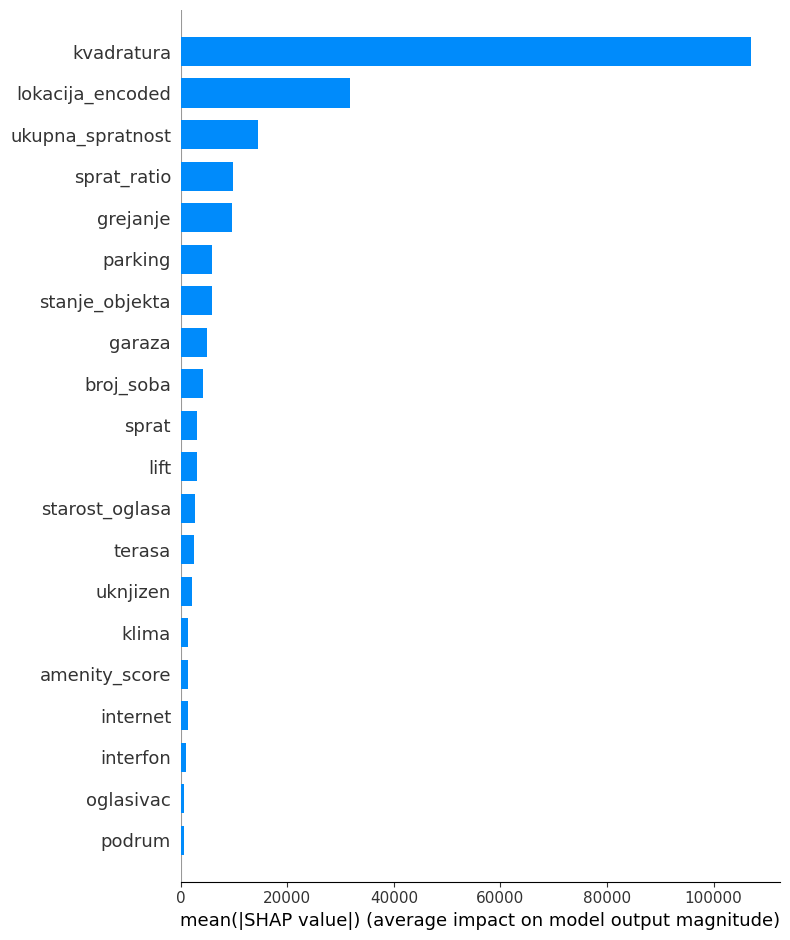

In [50]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_val)

shap.summary_plot(shap_values,X_val,plot_type = 'bar')

In [51]:
import optuna

In [52]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators',100,1000),
        'max_depth': trial.suggest_int('max_depth',3,7),
        'num_leaves': trial.suggest_int('num_leaves',20,200),
        'learning_rate': trial.suggest_float('learning_rate',0.01,0.3,log = True),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
        "subsample":       trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "random_state": 42,
        "n_jobs": 1
    }
    model = lgb.LGBMRegressor(**params)
    model.fit(X_train,Y_train)
    y_pred = model.predict(X_val)
    return mean_absolute_error(Y_val,y_pred)

In [53]:
study = optuna.create_study(direction = 'minimize')
study.optimize(objective,n_trials = 50)

[I 2026-05-10 17:03:46,129] A new study created in memory with name: no-name-30b46310-71d8-42c8-b7cb-c91e594ffb57
[I 2026-05-10 17:03:46,262] Trial 0 finished with value: 56756.961448891125 and parameters: {'n_estimators': 349, 'max_depth': 3, 'num_leaves': 194, 'learning_rate': 0.02362978433657503, 'min_child_samples': 47, 'subsample': 0.9802025454541761, 'colsample_bytree': 0.5165427140158477}. Best is trial 0 with value: 56756.961448891125.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000590 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 912
[LightGBM] [Info] Number of data points in the train set: 8930, number of used features: 22
[LightGBM] [Info] Start training from score 278135.526316
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

[I 2026-05-10 17:03:46,479] Trial 1 finished with value: 51867.8259408046 and parameters: {'n_estimators': 756, 'max_depth': 3, 'num_leaves': 193, 'learning_rate': 0.12069826655633166, 'min_child_samples': 19, 'subsample': 0.7442758401428162, 'colsample_bytree': 0.6658651666602654}. Best is trial 1 with value: 51867.8259408046.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-05-10 17:03:46,634] Trial 2 finished with value: 52233.06178203587 and parameters: {'n_estimators': 366, 'max_depth': 5, 'num_leaves': 84, 'learning_rate': 0.18679917942736654, 'min_child_samples': 77, 'subsample': 0.8905785922854336, 'colsample_bytree': 0.6302086519296952}. Best is trial 1 with value: 51867.8259408046.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-05-10 17:03:46,976] Trial 3 finished with value: 50833.069817806005 and parameters: {'n_estimators': 911, 'max_depth': 5, 'num_leaves': 24, 'learning_rate': 0.06821884082162098, 'min_child_samples': 80, 'subsample': 0.814114764438669, 'colsample_bytree': 0.8048342215390094}. Best is trial 3 with value: 50833.069817806005.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000756 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 912
[LightGBM] [Info] Number of data points in the train set: 8930, number of used features: 22
[LightGBM] [Info] Start training from score 278135.526316
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

[I 2026-05-10 17:03:47,468] Trial 4 finished with value: 50657.7346191639 and parameters: {'n_estimators': 819, 'max_depth': 7, 'num_leaves': 53, 'learning_rate': 0.01778183250227389, 'min_child_samples': 71, 'subsample': 0.6591022448583048, 'colsample_bytree': 0.750622900541436}. Best is trial 4 with value: 50657.7346191639.
[I 2026-05-10 17:03:47,633] Trial 5 finished with value: 52345.19603355642 and parameters: {'n_estimators': 356, 'max_depth': 6, 'num_leaves': 50, 'learning_rate': 0.2390675819671352, 'min_child_samples': 77, 'subsample': 0.9133661854402146, 'colsample_bytree': 0.7112061686735065}. Best is trial 4 with value: 50657.7346191639.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000721 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 912
[LightGBM] [Info] Number of data points in the train set: 8930, number of used features: 22
[LightGBM] [Info] Start training from score 278135.526316
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

[I 2026-05-10 17:03:48,060] Trial 6 finished with value: 49317.17192386489 and parameters: {'n_estimators': 793, 'max_depth': 7, 'num_leaves': 67, 'learning_rate': 0.07873076586518678, 'min_child_samples': 51, 'subsample': 0.9196203387937167, 'colsample_bytree': 0.6255026998241848}. Best is trial 6 with value: 49317.17192386489.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-05-10 17:03:48,487] Trial 7 finished with value: 53612.105572278546 and parameters: {'n_estimators': 898, 'max_depth': 5, 'num_leaves': 177, 'learning_rate': 0.2770158170331497, 'min_child_samples': 45, 'subsample': 0.910985774037738, 'colsample_bytree': 0.5672742474425373}. Best is trial 6 with value: 49317.17192386489.
[I 2026-05-10 17:03:48,692] Trial 8 finished with value: 57209.754738447176 and parameters: {'n_estimators': 230, 'max_depth': 7, 'num_leaves': 123, 'learning_rate': 0.011924928627332467, 'min_child_samples': 87, 'subsample': 0.5387281415240034, 'colsample_bytree': 0.6166341273640705}. Best is trial 6 with value: 49317.17192386489.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000671 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 912
[LightGBM] [Info] Number of data points in the train set: 8930, number of used features: 22
[LightGBM] [Info] Start training from score 278135.526316
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

[I 2026-05-10 17:03:48,811] Trial 9 finished with value: 52931.52777052942 and parameters: {'n_estimators': 388, 'max_depth': 3, 'num_leaves': 42, 'learning_rate': 0.07130640491290649, 'min_child_samples': 48, 'subsample': 0.9189172580644172, 'colsample_bytree': 0.9959091308055754}. Best is trial 6 with value: 49317.17192386489.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000830 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 912
[LightGBM] [Info] Number of data points in the train set: 8930, number of used features: 22
[LightGBM] [Info] Start training from score 278135.526316
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

[I 2026-05-10 17:03:49,208] Trial 10 finished with value: 48784.04775907874 and parameters: {'n_estimators': 631, 'max_depth': 6, 'num_leaves': 125, 'learning_rate': 0.03523807770546973, 'min_child_samples': 18, 'subsample': 0.7720466994164114, 'colsample_bytree': 0.8442724711850249}. Best is trial 10 with value: 48784.04775907874.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-05-10 17:03:49,646] Trial 11 finished with value: 48312.120222663754 and parameters: {'n_estimators': 646, 'max_depth': 6, 'num_leaves': 130, 'learning_rate': 0.035361718836804876, 'min_child_samples': 10, 'subsample': 0.7359983198349038, 'colsample_bytree': 0.8934481616989982}. Best is trial 11 with value: 48312.120222663754.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-05-10 17:03:50,024] Trial 12 finished with value: 47847.349516821996 and parameters: {'n_estimators': 556, 'max_depth': 6, 'num_leaves': 136, 'learning_rate': 0.03928983091669448, 'min_child_samples': 10, 'subsample': 0.7072784110448739, 'colsample_bytree': 0.8902470237356516}. Best is trial 12 with value: 47847.349516821996.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-05-10 17:03:50,419] Trial 13 finished with value: 48148.4898620176 and parameters: {'n_estimators': 576, 'max_depth': 6, 'num_leaves': 151, 'learning_rate': 0.03879901780797918, 'min_child_samples': 10, 'subsample': 0.6344713874672883, 'colsample_bytree': 0.9332596310207684}. Best is trial 12 with value: 47847.349516821996.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-05-10 17:03:50,623] Trial 14 finished with value: 51428.60188017237 and parameters: {'n_estimators': 526, 'max_depth': 4, 'num_leaves': 149, 'learning_rate': 0.03914122365763249, 'min_child_samples': 31, 'subsample': 0.6161624247177957, 'colsample_bytree': 0.9456991346511854}. Best is trial 12 with value: 47847.349516821996.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-05-10 17:03:50,951] Trial 15 finished with value: 50030.03066794326 and parameters: {'n_estimators': 529, 'max_depth': 6, 'num_leaves': 159, 'learning_rate': 0.02473000129807764, 'min_child_samples': 31, 'subsample': 0.6182576412345571, 'colsample_bytree': 0.9053354703640332}. Best is trial 12 with value: 47847.349516821996.
[I 2026-05-10 17:03:51,018] Trial 16 finished with value: 53899.52026941033 and parameters: {'n_estimators': 119, 'max_depth': 4, 'num_leaves': 92, 'learning_rate': 0.050554283566225156, 'min_child_samples': 32, 'subsample': 0.5092711323318715, 'colsample_bytree': 0.9978603969865326}. Best is trial 12 with value: 47847.349516821996.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000823 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 912
[LightGBM] [Info] Number of data points in the train set: 8930, number of used features: 22
[LightGBM] [Info] Start training from score 278135.526316
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

[I 2026-05-10 17:03:51,442] Trial 17 finished with value: 48132.6138251352 and parameters: {'n_estimators': 644, 'max_depth': 6, 'num_leaves': 154, 'learning_rate': 0.11758050014973302, 'min_child_samples': 10, 'subsample': 0.6853362721114729, 'colsample_bytree': 0.823454455718884}. Best is trial 12 with value: 47847.349516821996.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000770 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 912
[LightGBM] [Info] Number of data points in the train set: 8930, number of used features: 22
[LightGBM] [Info] Start training from score 278135.526316
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

[I 2026-05-10 17:03:51,715] Trial 18 finished with value: 49236.33605729104 and parameters: {'n_estimators': 705, 'max_depth': 5, 'num_leaves': 102, 'learning_rate': 0.11271034434020355, 'min_child_samples': 64, 'subsample': 0.6747464577887864, 'colsample_bytree': 0.8379715674124479}. Best is trial 12 with value: 47847.349516821996.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-05-10 17:03:52,038] Trial 19 finished with value: 49715.977959955344 and parameters: {'n_estimators': 463, 'max_depth': 7, 'num_leaves': 162, 'learning_rate': 0.12530398312863023, 'min_child_samples': 19, 'subsample': 0.8130083867466731, 'colsample_bytree': 0.7751558614659054}. Best is trial 12 with value: 47847.349516821996.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-05-10 17:03:52,354] Trial 20 finished with value: 52040.45527175231 and parameters: {'n_estimators': 966, 'max_depth': 4, 'num_leaves': 136, 'learning_rate': 0.16459702416729616, 'min_child_samples': 99, 'subsample': 0.5591325239087295, 'colsample_bytree': 0.8632245393377714}. Best is trial 12 with value: 47847.349516821996.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-05-10 17:03:52,752] Trial 21 finished with value: 47979.35832802759 and parameters: {'n_estimators': 607, 'max_depth': 6, 'num_leaves': 172, 'learning_rate': 0.04848057964476786, 'min_child_samples': 12, 'subsample': 0.6881923308585717, 'colsample_bytree': 0.9433551861959754}. Best is trial 12 with value: 47847.349516821996.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000759 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 912
[LightGBM] [Info] Number of data points in the train set: 8930, number of used features: 22
[LightGBM] [Info] Start training from score 278135.526316
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

[I 2026-05-10 17:03:53,124] Trial 22 finished with value: 49332.17149281102 and parameters: {'n_estimators': 683, 'max_depth': 6, 'num_leaves': 177, 'learning_rate': 0.052473988640783335, 'min_child_samples': 25, 'subsample': 0.711064750928213, 'colsample_bytree': 0.8187132302814446}. Best is trial 12 with value: 47847.349516821996.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-05-10 17:03:53,365] Trial 23 finished with value: 48434.083740972485 and parameters: {'n_estimators': 459, 'max_depth': 6, 'num_leaves': 172, 'learning_rate': 0.09213997451876572, 'min_child_samples': 39, 'subsample': 0.6946175644957895, 'colsample_bytree': 0.9533385197473414}. Best is trial 12 with value: 47847.349516821996.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-05-10 17:03:53,694] Trial 24 finished with value: 49964.98547184984 and parameters: {'n_estimators': 598, 'max_depth': 5, 'num_leaves': 141, 'learning_rate': 0.024512181596362027, 'min_child_samples': 11, 'subsample': 0.7815567792337712, 'colsample_bytree': 0.8879948800349036}. Best is trial 12 with value: 47847.349516821996.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-05-10 17:03:54,004] Trial 25 finished with value: 49251.727546502625 and parameters: {'n_estimators': 470, 'max_depth': 7, 'num_leaves': 113, 'learning_rate': 0.056313078416642015, 'min_child_samples': 25, 'subsample': 0.584102677514472, 'colsample_bytree': 0.7714401213772039}. Best is trial 12 with value: 47847.349516821996.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000785 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 912
[LightGBM] [Info] Number of data points in the train set: 8930, number of used features: 22
[LightGBM] [Info] Start training from score 278135.526316
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

[I 2026-05-10 17:03:54,357] Trial 26 finished with value: 49848.76896302489 and parameters: {'n_estimators': 737, 'max_depth': 6, 'num_leaves': 186, 'learning_rate': 0.09476425702195092, 'min_child_samples': 60, 'subsample': 0.7102785518862005, 'colsample_bytree': 0.9257344324717103}. Best is trial 12 with value: 47847.349516821996.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-05-10 17:03:54,673] Trial 27 finished with value: 52197.49887560714 and parameters: {'n_estimators': 550, 'max_depth': 5, 'num_leaves': 165, 'learning_rate': 0.014558464669352863, 'min_child_samples': 18, 'subsample': 0.8405279911275474, 'colsample_bytree': 0.8718387712681832}. Best is trial 12 with value: 47847.349516821996.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000853 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 912
[LightGBM] [Info] Number of data points in the train set: 8930, number of used features: 22
[LightGBM] [Info] Start training from score 278135.526316
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

[I 2026-05-10 17:03:55,116] Trial 28 finished with value: 48531.94562639808 and parameters: {'n_estimators': 833, 'max_depth': 6, 'num_leaves': 147, 'learning_rate': 0.030628803029559077, 'min_child_samples': 38, 'subsample': 0.648925902029519, 'colsample_bytree': 0.9691660838966815}. Best is trial 12 with value: 47847.349516821996.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000724 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 912
[LightGBM] [Info] Number of data points in the train set: 8930, number of used features: 22
[LightGBM] [Info] Start training from score 278135.526316
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

[I 2026-05-10 17:03:55,337] Trial 29 finished with value: 49948.30037906272 and parameters: {'n_estimators': 298, 'max_depth': 7, 'num_leaves': 188, 'learning_rate': 0.04825848353627436, 'min_child_samples': 25, 'subsample': 0.5836469123840192, 'colsample_bytree': 0.7183153660509035}. Best is trial 12 with value: 47847.349516821996.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000752 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 912
[LightGBM] [Info] Number of data points in the train set: 8930, number of used features: 22
[LightGBM] [Info] Start training from score 278135.526316
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

[I 2026-05-10 17:03:55,791] Trial 30 finished with value: 49232.58534985636 and parameters: {'n_estimators': 667, 'max_depth': 6, 'num_leaves': 199, 'learning_rate': 0.017482587726164008, 'min_child_samples': 15, 'subsample': 0.9899524564962515, 'colsample_bytree': 0.8064439645369315}. Best is trial 12 with value: 47847.349516821996.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000790 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 912
[LightGBM] [Info] Number of data points in the train set: 8930, number of used features: 22
[LightGBM] [Info] Start training from score 278135.526316
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

[I 2026-05-10 17:03:56,185] Trial 31 finished with value: 49129.29680028248 and parameters: {'n_estimators': 617, 'max_depth': 6, 'num_leaves': 156, 'learning_rate': 0.044561940045083265, 'min_child_samples': 13, 'subsample': 0.6299895596747656, 'colsample_bytree': 0.920942392230756}. Best is trial 12 with value: 47847.349516821996.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-05-10 17:03:56,539] Trial 32 finished with value: 50073.215925181525 and parameters: {'n_estimators': 578, 'max_depth': 6, 'num_leaves': 116, 'learning_rate': 0.029204771067865627, 'min_child_samples': 25, 'subsample': 0.6792710530765423, 'colsample_bytree': 0.9641992064522917}. Best is trial 12 with value: 47847.349516821996.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-05-10 17:03:56,810] Trial 33 finished with value: 49375.91090783897 and parameters: {'n_estimators': 499, 'max_depth': 5, 'num_leaves': 148, 'learning_rate': 0.04019483066770911, 'min_child_samples': 11, 'subsample': 0.7469609574465091, 'colsample_bytree': 0.9177833187034756}. Best is trial 12 with value: 47847.349516821996.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-05-10 17:03:57,012] Trial 34 finished with value: 50181.870758415775 and parameters: {'n_estimators': 408, 'max_depth': 5, 'num_leaves': 134, 'learning_rate': 0.060867026792489634, 'min_child_samples': 21, 'subsample': 0.7132105475968076, 'colsample_bytree': 0.8764163243877884}. Best is trial 12 with value: 47847.349516821996.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000766 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 912
[LightGBM] [Info] Number of data points in the train set: 8930, number of used features: 22
[LightGBM] [Info] Start training from score 278135.526316
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

[I 2026-05-10 17:03:57,674] Trial 35 finished with value: 48254.20807827968 and parameters: {'n_estimators': 744, 'max_depth': 7, 'num_leaves': 172, 'learning_rate': 0.019972258695296393, 'min_child_samples': 10, 'subsample': 0.6579528009788533, 'colsample_bytree': 0.8363981827778003}. Best is trial 12 with value: 47847.349516821996.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000819 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 912
[LightGBM] [Info] Number of data points in the train set: 8930, number of used features: 22
[LightGBM] [Info] Start training from score 278135.526316
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

[I 2026-05-10 17:03:58,045] Trial 36 finished with value: 51261.8050428639 and parameters: {'n_estimators': 572, 'max_depth': 6, 'num_leaves': 153, 'learning_rate': 0.19205617132153638, 'min_child_samples': 16, 'subsample': 0.6019609057063605, 'colsample_bytree': 0.9411806840393115}. Best is trial 12 with value: 47847.349516821996.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-05-10 17:03:58,266] Trial 37 finished with value: 51848.50265721718 and parameters: {'n_estimators': 427, 'max_depth': 5, 'num_leaves': 140, 'learning_rate': 0.02995070362119307, 'min_child_samples': 22, 'subsample': 0.641658540825664, 'colsample_bytree': 0.7921489578446697}. Best is trial 12 with value: 47847.349516821996.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-05-10 17:03:58,675] Trial 38 finished with value: 48174.85934181985 and parameters: {'n_estimators': 786, 'max_depth': 6, 'num_leaves': 165, 'learning_rate': 0.06400235096629357, 'min_child_samples': 33, 'subsample': 0.7778159048842145, 'colsample_bytree': 0.8508236733182984}. Best is trial 12 with value: 47847.349516821996.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-05-10 17:03:59,103] Trial 39 finished with value: 50960.51046714818 and parameters: {'n_estimators': 708, 'max_depth': 7, 'num_leaves': 188, 'learning_rate': 0.1607569082231583, 'min_child_samples': 38, 'subsample': 0.7256425507744612, 'colsample_bytree': 0.7395429289473808}. Best is trial 12 with value: 47847.349516821996.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000665 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 912
[LightGBM] [Info] Number of data points in the train set: 8930, number of used features: 22
[LightGBM] [Info] Start training from score 278135.526316
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

[I 2026-05-10 17:03:59,327] Trial 40 finished with value: 49546.15003178262 and parameters: {'n_estimators': 308, 'max_depth': 7, 'num_leaves': 100, 'learning_rate': 0.08450745957583947, 'min_child_samples': 15, 'subsample': 0.6811685022608103, 'colsample_bytree': 0.6846782626639869}. Best is trial 12 with value: 47847.349516821996.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000766 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 912
[LightGBM] [Info] Number of data points in the train set: 8930, number of used features: 22
[LightGBM] [Info] Start training from score 278135.526316
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

[I 2026-05-10 17:03:59,772] Trial 41 finished with value: 48419.907656147625 and parameters: {'n_estimators': 858, 'max_depth': 6, 'num_leaves': 165, 'learning_rate': 0.06277361194614361, 'min_child_samples': 32, 'subsample': 0.7700060129953379, 'colsample_bytree': 0.8504056992709632}. Best is trial 12 with value: 47847.349516821996.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000803 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 912
[LightGBM] [Info] Number of data points in the train set: 8930, number of used features: 22
[LightGBM] [Info] Start training from score 278135.526316
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

[I 2026-05-10 17:04:00,140] Trial 42 finished with value: 47724.046523486046 and parameters: {'n_estimators': 630, 'max_depth': 6, 'num_leaves': 180, 'learning_rate': 0.07355459720639866, 'min_child_samples': 20, 'subsample': 0.8047657312322102, 'colsample_bytree': 0.8934895589420562}. Best is trial 42 with value: 47724.046523486046.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-05-10 17:04:00,509] Trial 43 finished with value: 49891.49016856954 and parameters: {'n_estimators': 615, 'max_depth': 6, 'num_leaves': 181, 'learning_rate': 0.11132159723906761, 'min_child_samples': 21, 'subsample': 0.8227838385008207, 'colsample_bytree': 0.9740287178077214}. Best is trial 42 with value: 47724.046523486046.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-05-10 17:04:00,890] Trial 44 finished with value: 48008.30960288472 and parameters: {'n_estimators': 651, 'max_depth': 6, 'num_leaves': 200, 'learning_rate': 0.07779465295225448, 'min_child_samples': 16, 'subsample': 0.7533588847407384, 'colsample_bytree': 0.9082657961794524}. Best is trial 42 with value: 47724.046523486046.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-05-10 17:04:01,207] Trial 45 finished with value: 49052.932459980875 and parameters: {'n_estimators': 654, 'max_depth': 5, 'num_leaves': 199, 'learning_rate': 0.13616899956313294, 'min_child_samples': 16, 'subsample': 0.8519199519669974, 'colsample_bytree': 0.903279283934206}. Best is trial 42 with value: 47724.046523486046.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000579 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 912
[LightGBM] [Info] Number of data points in the train set: 8930, number of used features: 22
[LightGBM] [Info] Start training from score 278135.526316
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

[I 2026-05-10 17:04:01,615] Trial 46 finished with value: 47932.56501253325 and parameters: {'n_estimators': 705, 'max_depth': 6, 'num_leaves': 192, 'learning_rate': 0.07429125278423993, 'min_child_samples': 14, 'subsample': 0.7545490306681449, 'colsample_bytree': 0.5068287545979199}. Best is trial 42 with value: 47724.046523486046.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-05-10 17:04:02,088] Trial 47 finished with value: 49228.407892435134 and parameters: {'n_estimators': 746, 'max_depth': 7, 'num_leaves': 193, 'learning_rate': 0.07341155558116837, 'min_child_samples': 28, 'subsample': 0.7573473116041994, 'colsample_bytree': 0.5059840836558225}. Best is trial 42 with value: 47724.046523486046.


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000674 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 912
[LightGBM] [Info] Number of data points in the train set: 8930, number of used features: 22
[LightGBM] [Info] Start training from score 278135.526316
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

[I 2026-05-10 17:04:02,473] Trial 48 finished with value: 49261.837570792595 and parameters: {'n_estimators': 790, 'max_depth': 6, 'num_leaves': 71, 'learning_rate': 0.07972453422616017, 'min_child_samples': 43, 'subsample': 0.7991677189176342, 'colsample_bytree': 0.658996585298932}. Best is trial 42 with value: 47724.046523486046.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-05-10 17:04:02,678] Trial 49 finished with value: 51814.56747247068 and parameters: {'n_estimators': 702, 'max_depth': 3, 'num_leaves': 181, 'learning_rate': 0.0964801539087847, 'min_child_samples': 51, 'subsample': 0.865621599435444, 'colsample_bytree': 0.9830573772409638}. Best is trial 42 with value: 47724.046523486046.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

In [54]:
print(f"Najbolje MAE: {study.best_value: ,.0f}EUR")
print(f"Najbolj parametri: {study.best_params}")

Najbolje MAE:  47,724EUR
Najbolj parametri: {'n_estimators': 630, 'max_depth': 6, 'num_leaves': 180, 'learning_rate': 0.07355459720639866, 'min_child_samples': 20, 'subsample': 0.8047657312322102, 'colsample_bytree': 0.8934895589420562}


In [55]:
best_model = lgb.LGBMRegressor(
    **study.best_params,
    random_state=42,
    n_jobs=1
)
best_model.fit(X_train, Y_train)

y_pred_test = best_model.predict(X_test)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000871 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 912
[LightGBM] [Info] Number of data points in the train set: 8930, number of used features: 22
[LightGBM] [Info] Start training from score 278135.526316
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

In [57]:
print("\n=== LightGBM (optimizovan) — TEST ===")
print(f"MAE:  {mean_absolute_error(Y_test, best_model.predict(X_test)):,.0f} EUR")
print(f"RMSE: {root_mean_squared_error(Y_test, best_model.predict(X_test)):,.0f} EUR")
print(f"R²:   {r2_score(Y_test, best_model.predict(X_test)):.3f}")


=== LightGBM (optimizovan) — TEST ===
MAE:  53,729 EUR
RMSE: 87,202 EUR
R²:   0.832


In [58]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import StackingRegressor, RandomForestRegressor
from catboost import CatBoostRegressor

In [59]:
# for col in cat_cols:
#     X_train[col] = X_train[col].fillna("Unknown").astype(str)
#     X_val[col]   = X_val[col].fillna("Unknown").astype(str)
#     X_test[col]  = X_test[col].fillna("Unknown").astype(str)

cat_model = CatBoostRegressor(random_state=42, verbose=0, cat_features=cat_cols)
cat_model.fit(X_train, Y_train)
y_pred_cat = cat_model.predict(X_val)

print("=== CATBOOST ===")
print(f"MAE:  {mean_absolute_error(Y_val, y_pred_cat):,.0f} EUR")
print(f"RMSE: {root_mean_squared_error(Y_val, y_pred_cat):,.0f} EUR")
print(f"R²:   {r2_score(Y_val, y_pred_cat):.3f}")

=== CATBOOST ===
MAE:  50,601 EUR
RMSE: 81,738 EUR
R²:   0.838


In [61]:
y_pred_cat_test = cat_model.predict(X_test)

print("=== CATBOOST TEST SET ===")
print(f"MAE:  {mean_absolute_error(Y_test, y_pred_cat_test):,.0f} EUR")
print(f"RMSE: {root_mean_squared_error(Y_test, y_pred_cat_test):,.0f} EUR")
print(f"R²:   {r2_score(Y_test, y_pred_cat_test):.3f}")

=== CATBOOST TEST SET ===
MAE:  54,803 EUR
RMSE: 92,592 EUR
R²:   0.810


In [62]:
from sklearn.preprocessing import LabelEncoder

X_train_rf = X_train.copy()
X_val_rf = X_val.copy()
X_test_rf = X_test.copy()

le = LabelEncoder()
for col in cat_cols:
    X_train_rf[col] = le.fit_transform(X_train_rf[col].astype(str))
    X_val_rf[col]   = le.transform(X_val_rf[col].astype(str))
    X_test_rf[col]  = le.transform(X_test_rf[col].astype(str))

rf_model = RandomForestRegressor(random_state=42, n_jobs=1)
rf_model.fit(X_train_rf, Y_train)
y_pred_rf = rf_model.predict(X_val_rf)

print("=== RANDOM FOREST ===")
print(f"MAE:  {mean_absolute_error(Y_val, y_pred_rf):,.0f} EUR")
print(f"RMSE: {root_mean_squared_error(Y_val, y_pred_rf):,.0f} EUR")
print(f"R²:   {r2_score(Y_val, y_pred_rf):.3f}")

=== RANDOM FOREST ===
MAE:  48,594 EUR
RMSE: 79,974 EUR
R²:   0.845
